In [2]:
import numpy as np
import mogptk
import matplotlib.pyplot as plt
import random
seed = 100
random.seed(seed)
np.random.seed(seed)

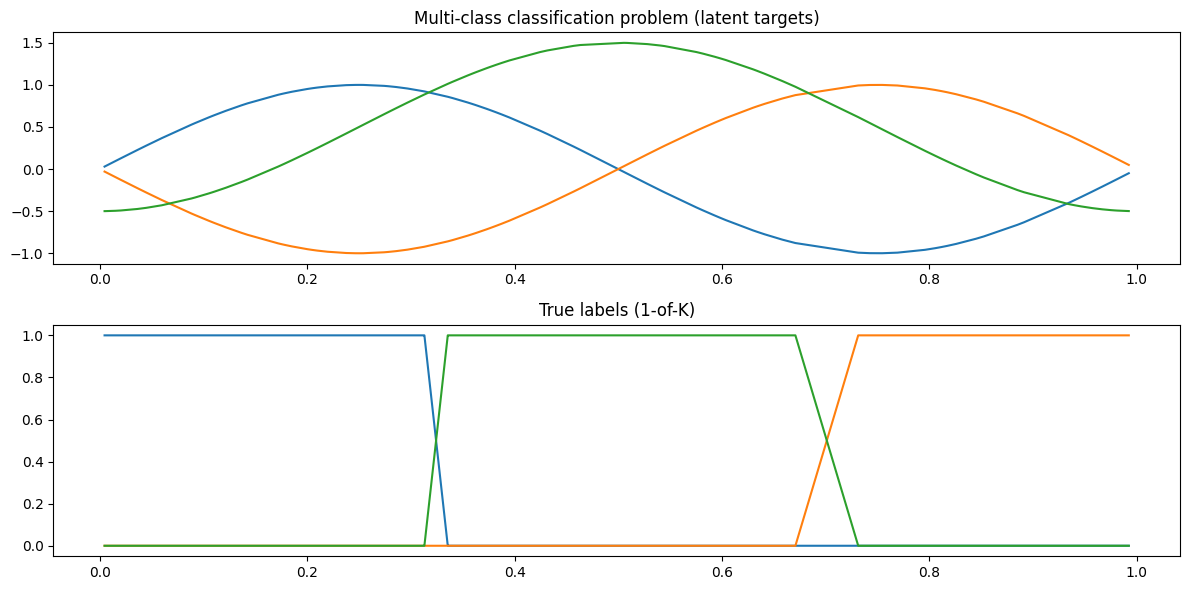

N = 100 K = 3


In [3]:
N = 100
X = np.random.rand(N, 1)

t1 = (np.sin(2 * np.pi * X)).reshape(N, 1)
t2 = (-np.sin(2 * np.pi * X)).reshape(N, 1)
t3 = (-np.sin(2 * np.pi * (X + 0.25)) + 0.5).reshape(N, 1)

t = np.concatenate((t1, t2, t3), axis=1)

idx = np.argsort(X, axis=0).flatten()
X = X[idx]
t = t[idx, :]

y = (np.argmax(t, axis=1).reshape(-1, 1).astype(float) + 1)  # labels 1..K
K = len(np.unique(y))

def one_of_K(y, K):
    Yhat = np.ones((y.shape[0], K))
    for k in range(K):
        Yhat[:, k, None] = (y == k + 1).astype(int)
    return Yhat

Yhat = one_of_K(y, K)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(X, t)
plt.title("Multi-class classification problem (latent targets)")
plt.subplot(2, 1, 2)
plt.plot(X, Yhat)
plt.title("True labels (1-of-K)")
plt.tight_layout()
plt.show()

print("N =", N, "K =", K)

In [4]:
seed = 1
np.random.seed(seed)

Ntest = 200

# Training set 
Xtrain = X.reshape((N, 1))
ytrain = y

# Test set
Xtest = np.linspace(0, 1, Ntest).reshape((Ntest, 1))

t1 = (np.sin(2 * np.pi * Xtest)).reshape(Ntest, 1)
t2 = (-np.sin(2 * np.pi * Xtest)).reshape(Ntest, 1)
t3 = (-np.sin(2 * np.pi * (Xtest + 0.25)) + 0.5).reshape(Ntest, 1)

ttest = np.concatenate((t1, t2, t3), axis=1)
ytest = (np.argmax(ttest, axis=1).reshape(-1, 1).astype(float) + 1)  # labels 1..K

print("Xtrain:", Xtrain.shape, "ytrain:", ytrain.shape)
print("Xtest :", Xtest.shape, "ytest :", ytest.shape)

Xtrain: (100, 1) ytrain: (100, 1)
Xtest : (200, 1) ytest : (200, 1)


In [5]:
def Sigmoid(f_r):
    return 1 / (1 + np.exp(-f_r))

def multiple_annotators(R, NrP, Xtrain, ytrain):
    N = Xtrain.size
    Kloc = len(np.unique(ytrain))

    # latent factor functions u_q
    u_q = np.empty((Xtrain.shape[0], 3))
    u_q[:, 0, None] = (
        4.5 * np.cos(2 * np.pi * Xtrain + 1.5 * np.pi)
        - 3 * np.sin(4.3 * np.pi * Xtrain + 0.3 * np.pi)
    )
    u_q[:, 1, None] = (
        4.5 * np.cos(1.5 * np.pi * Xtrain + 0.5 * np.pi)
        + 5 * np.sin(3 * np.pi * Xtrain + 1.5 * np.pi)
    )
    u_q[:, 2, None] = 1

    # combination weights W[q][r]
    W = []
    W.append(np.array(([[0.4], [0.7], [-0.5], [0], [-0.7]])))     # q=1
    W.append(np.array(([[0.4], [-1.0], [-0.1], [-0.8], [1.0]])))  # q=2
    W.append(np.array(([[3.1], [-1.8], [-0.6], [-1.2], [1.0]])))  # q=3

    Lam_r = []
    for r in range(R):
        f_r = np.zeros((Xtrain.shape[0], 1))
        for q in range(3):
            f_r += W[q][r].T * u_q[:, q, None]
        lam_r = Sigmoid(f_r)
        lam_r[lam_r > 0.5] = 1
        lam_r[lam_r <= 0.5] = 0
        Lam_r.append(lam_r)

    # Simulate annotations (Ytrain is always 1..K for all entries, like demo)
    seed = 100
    np.random.seed(seed)
    Ytrain = np.ones((N, R))
    for r in range(R):
        aux = ytrain.copy()
        for n in range(N):
            if Lam_r[r][n] == 0:
                labels = np.arange(1, Kloc + 1)
                a = np.where(labels == ytrain[n])
                labels = np.delete(labels, a)
                idxlabels = np.random.permutation(Kloc - 1)
                aux[n] = labels[idxlabels[0]]
        Ytrain[:, r] = aux.flatten()

    # Annotation mask iAnn
    seed = 100
    np.random.seed(seed)
    iAnn = np.zeros((N, R), dtype=int)
    Nr = np.ones((R), dtype=int) * int(np.floor(N * NrP))
    for r in range(R):
        if r < R - 1:
            indexR = np.random.permutation(range(N))[: Nr[r]]
            iAnn[indexR, r] = 1
        else:
            iSimm = np.sum(iAnn, axis=1)
            idxZero = np.asarray([i for (i, val) in enumerate(iSimm) if val == 0])
            Nzeros = idxZero.shape[0]
            idx2Choose = np.arange(N)
            if Nzeros == 0:
                indexR = np.random.permutation(range(N))[: Nr[r]]
                iAnn[indexR, r] = 1
            else:
                idx2Choose = np.delete(idx2Choose, idxZero)
                N2chose = idx2Choose.shape[0]
                idxNoZero = np.random.permutation(N2chose)[: (Nr[r] - Nzeros)]
                idxTot = np.concatenate((idxZero, idx2Choose[idxNoZero]))
                iAnn[idxTot, r] = 1

    # Demo intent: all samples labeled at least once (note: demo has a bug: doesn't raise)
    iSimm = np.sum(iAnn, axis=1)
    if (iSimm == 0).any():
        raise ValueError("all the samples must be labeled at least once")

    Vref = -1e-20
    return Lam_r, Ytrain, iAnn, Vref


R = 5      # number of annotators
NrP = 1.0  # percentage labeled by each annotator (start with 1.0 like a sanity check)

Z_r, Ytrain, iAnn, Vref = multiple_annotators(R, NrP, Xtrain, ytrain)

print("Ytrain:", Ytrain.shape, "iAnn:", iAnn.shape, "Vref:", Vref)
print("Unique labels in Ytrain:", np.unique(Ytrain))
print("iAnn sums per annotator:", iAnn.sum(axis=0))
print("iAnn sums per point min/max:", iAnn.sum(axis=1).min(), iAnn.sum(axis=1).max())

Ytrain: (100, 5) iAnn: (100, 5) Vref: -1e-20
Unique labels in Ytrain: [1. 2. 3.]
iAnn sums per annotator: [100 100 100 100 100]
iAnn sums per point min/max: 5 5


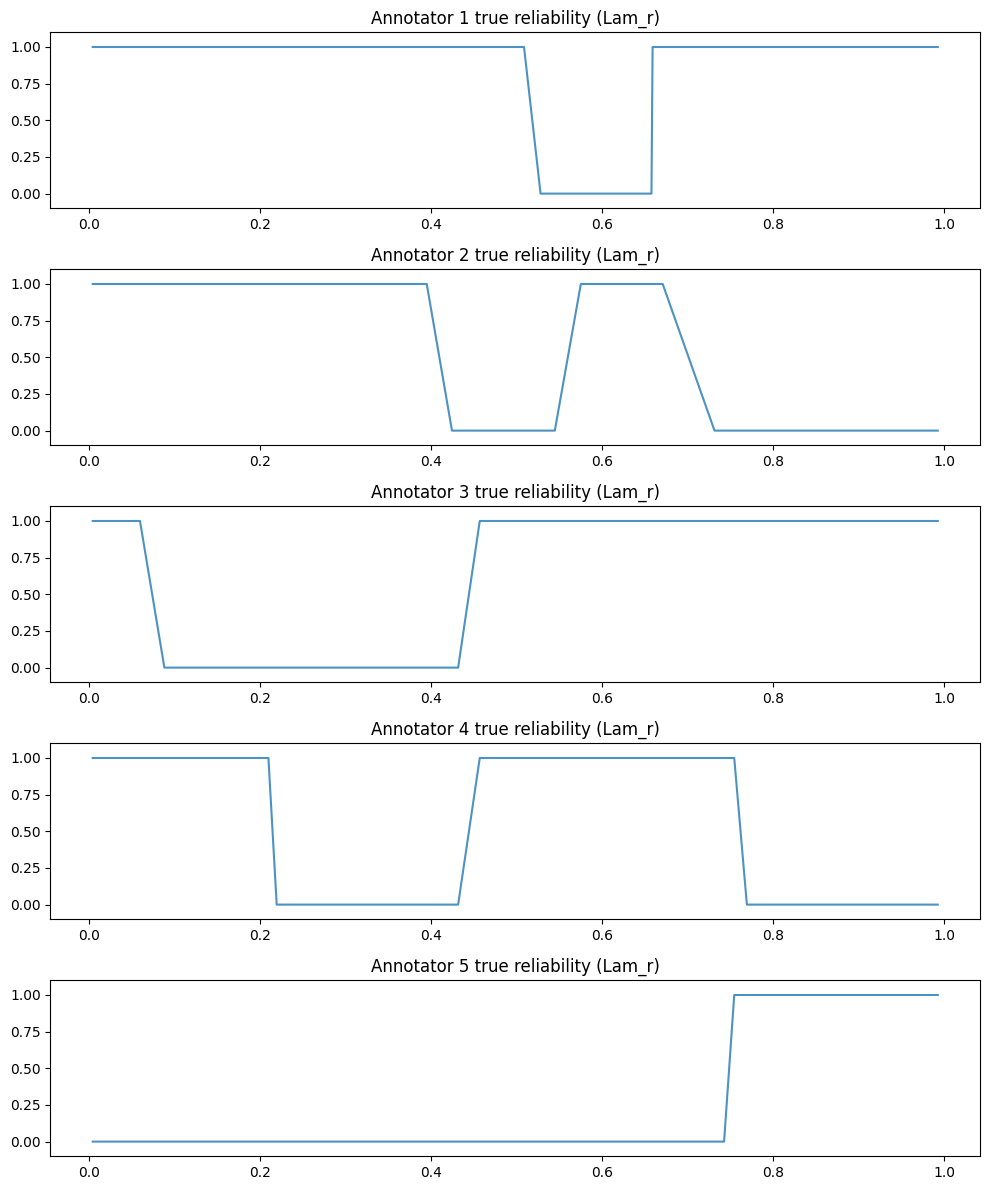

In [6]:
plt.figure(figsize=(10, 12))
for r in range(R):
    plt.subplot(R, 1, r + 1)
    plt.plot(Xtrain, Z_r[r], alpha=0.8)
    plt.ylim(-0.1, 1.1)
    plt.title(f"Annotator {r+1} true reliability (Lam_r)")
plt.tight_layout()
plt.show()

In [7]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

Xtr = torch.tensor(Xtrain, dtype=dtype, device=device)
Ytr = torch.tensor(Ytrain, dtype=dtype, device=device)   # (N, R) en {1..K}
iAnn_t = torch.tensor(iAnn, dtype=dtype, device=device)  # (N, R) en {0,1}

Xte = torch.tensor(Xtest, dtype=dtype, device=device)

print("device:", device)
print("Xtr:", Xtr.shape, Xtr.dtype)
print("Ytr:", Ytr.shape, Ytr.dtype, "min/max:", Ytr.min().item(), Ytr.max().item())
print("iAnn:", iAnn_t.shape, iAnn_t.dtype, "unique:", torch.unique(iAnn_t).tolist())

device: cpu
Xtr: torch.Size([100, 1]) torch.float32
Ytr: torch.Size([100, 5]) torch.float32 min/max: 1.0 3.0
iAnn: torch.Size([100, 5]) torch.float32 unique: [1.0]


In [8]:
from mogptk.gpr.likelihood import MultiClassMA


lik = MultiClassMA(K=K, R=R, iAnn=iAnn_t, beta=0.2, use_gce=True)

print(lik.name() if hasattr(lik, "name") else lik)

MultiClassMA(beta=0.2, K=3, R=5, Q=8)


Built mogptk dataset with channels: 8


<Axes: title={'center': 'Placeholder y (majority vote) — channel 1/8'}, xlabel='X', ylabel='Y'>

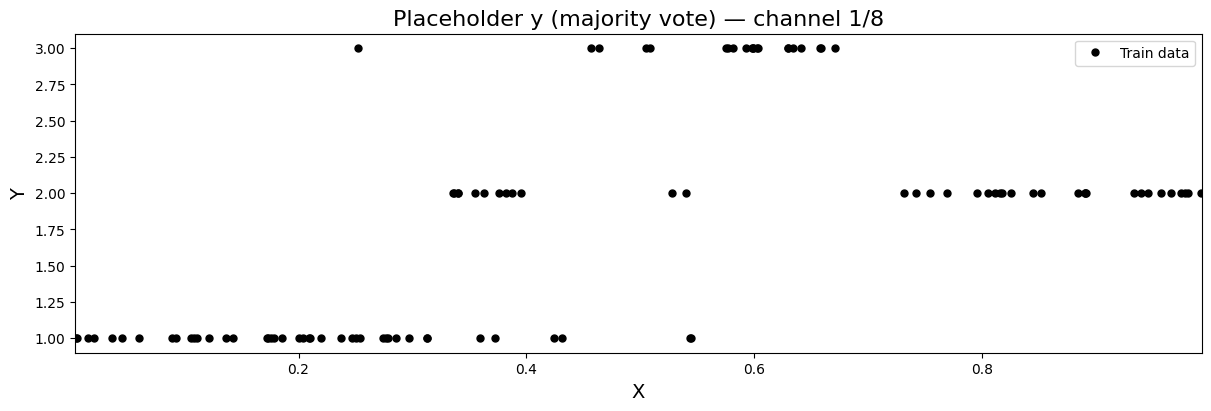

In [9]:
def MAjVot(Y, K):
    Nloc, Rloc = Y.shape
    Yhat = np.zeros((Nloc, 1))
    for n in range(Nloc):
        votes = np.zeros((K, 1))
        for r in range(Rloc):
            for k in range(K):
                if Y[n, r] == k + 1:
                    votes[k] = votes[k] + 1
        Yhat[n] = np.argmax(votes) + 1
    return Yhat
y_mv = MAjVot(Ytrain, K).astype(float)

Q = K + R
dataset_items = []
for q in range(Q):
    dataset_items.append(mogptk.Data(Xtrain, y_mv, name=f"MA demo channel {q+1}/{Q}"))

data = mogptk.DataSet(*dataset_items)

print("Built mogptk dataset with channels:", len(data))
data[0].plot(title=f"Placeholder y (majority vote) — channel 1/{Q}")

In [77]:
kernels = [mogptk.gpr.SquaredExponentialKernel() for _ in range(Q)]

idx = K + 0  # anotador 1

kernels[idx].lengthscale.assign(0.03)  
kernels[idx].magnitude.assign(0.8)
kernels[idx+1].lengthscale.assign(0.02)  
kernels[idx+1].magnitude.assign(0.8)
kernel = mogptk.gpr.IndependentMultiOutputKernel(*kernels, output_dims=Q)


print("Q =", Q)
print(kernel)

Q = 8
IndependentMultiOutputKernel(
  (kernels): ModuleList(
    (0-7): 8 x SquaredExponentialKernel()
  )
)


In [38]:
kernels = []
for i in range(K):
    k = mogptk.gpr.MaternKernel(nu=1.5)   # Matern 3/2
    k.lengthscale.assign(0.01)
    k.magnitude.assign(0.5)
    kernels.append(k)

# kernels de anotador (3..7)
for j in range(R):
    k = mogptk.gpr.SquaredExponentialKernel()
    k.lengthscale.assign(0.01)
    k.magnitude.assign(0.5)
    kernels.append(k)

kernel = mogptk.gpr.LinearModelOfCoregionalizationKernel(*kernels, output_dims=Q)

In [39]:
kernels = []
for j in range(Q):
    k = mogptk.gpr.SquaredExponentialKernel()
    k.lengthscale.assign(0.15)
    k.magnitude.assign(0.8)
    kernels.append(k)

kernel = mogptk.gpr.LinearModelOfCoregionalizationKernel(*kernels, output_dims=Q)

In [105]:
M = 20 

# Xtrain debe ser (N,1) o (N,)
minX = float(np.min(Xtrain))
maxX = float(np.max(Xtrain))

Zx = np.linspace(minX, maxX, M, dtype=np.float32).reshape(-1, 1)  # (M,1)

Z_list = []
for c in range(Q):
    ch = np.full((M, 1), c, dtype=np.float32)           # (M,1)
    Zc = np.concatenate([ch, Zx], axis=1)               # (M,2): [channel, x]
    Z_list.append(Zc)

Zinit = np.vstack(Z_list).astype(np.float32)            # (Q*M, 2)
Zinit_t = torch.tensor(Zinit, dtype=dtype, device=device)

print("Zinit_t shape:", Zinit_t.shape)  # (80,2) para Q=8,M=10

Zinit_t shape: torch.Size([160, 2])


In [106]:
mlik = mogptk.gpr.MultiLatentLikelihood(lik, mc_samples=10)
mlik.set_y_full(Ytr)   # (N,R) labels completos
inference = mogptk.Hensman(
    likelihood=mlik,
    inducing_points=Zinit_t,        # tensor (80,2) -> total fijo
)

model = mogptk.Model(data, kernel, inference=inference)

#print(model)

Starting optimization using Adam
‣ Model: SparseHensman
  ‣ Kernel: IndependentMultiOutputKernel[SquaredExponentialKernel,SquaredExponentialKernel,SquaredExponentialKernel,SquaredExponentialKernel,SquaredExponentialKernel,SquaredExponentialKernel,SquaredExponentialKernel,SquaredExponentialKernel]
  ‣ Likelihood: MultiLatent[MultiClassMA(beta=0.2, K=3, R=5, Q=8), Q=8]
‣ Channels: 8
‣ Parameters: 13216
‣ Training points: 800
‣ Iterations: 2000
     0/2000   0:00:00  loss=     711.572
   296/2000   0:00:10  loss=     269.372
   637/2000   0:00:20  loss=     260.342
   978/2000   0:00:30  loss=      256.46
  1322/2000   0:00:40  loss=     283.353
  1662/2000   0:00:50  loss=      256.49
  2000/2000   0:00:59  loss=     255.659
Optimization finished in 59.772 seconds


(<Figure size 1200x400 with 1 Axes>, <Axes: xlabel='Iteration', ylabel='Loss'>)

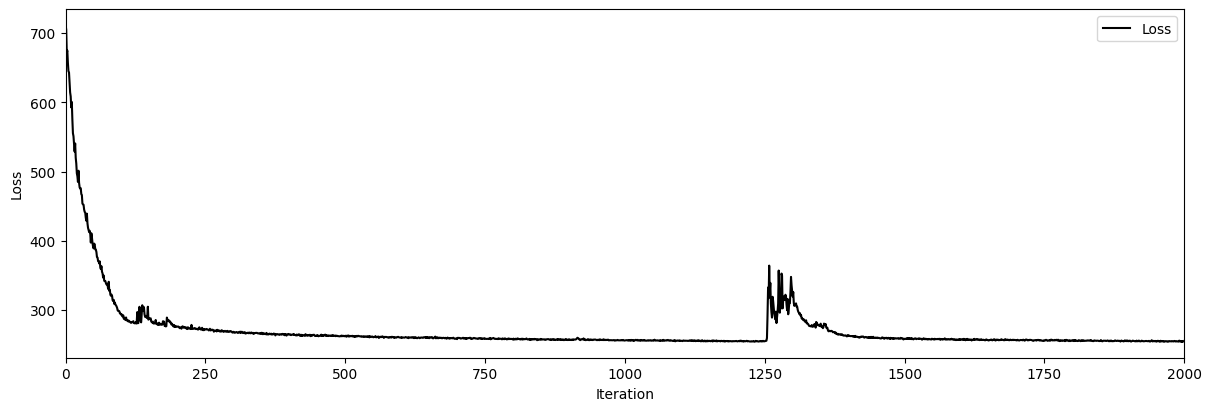

In [107]:
model.train(iters=2000, verbose=True, lr=0.01,  jit=False)
model.plot_losses()

In [108]:

def build_X_lmc(X1d_np: np.ndarray, Q: int) -> torch.Tensor:
    """
    X1d_np: (N,1) float
    return: (N*Q, 2) torch
      col0 = channel_id  (int)
      col1 = x           (float)
    Orden por bloques: canal 0 con todos los x, luego canal 1, etc.
    """
    X1d_np = X1d_np.reshape(-1, 1)
    N = X1d_np.shape[0]

    # Repetimos X por canal (bloques)
    x_rep = np.tile(X1d_np, (Q, 1)).astype(np.float32)         # (N*Q, 1)

    # Channel ids (enteros) por bloques
    chan = np.repeat(np.arange(Q, dtype=np.int64), N)          # (N*Q,)

    # X = [channel_id, x]
    X2 = np.concatenate([chan.reshape(-1, 1).astype(np.float32), x_rep], axis=1)  # (N*Q, 2)
    # NOTA: mogptk chequea integridad vía cast a long y comparación; float 0.0,1.0,... pasa.
    # Si prefieres, puedes mantenerlo en float y listo; el check exige "valores enteros".
    return torch.tensor(X2, dtype=dtype, device=device)

def unstack_blocked(t: torch.Tensor, N: int, Q: int) -> torch.Tensor:
    """
    t: (N*Q, 1) o (N*Q,) -> (N, Q) asumiendo orden por bloques por canal.
    """
    if t.ndim == 2 and t.shape[1] == 1:
        t = t.squeeze(1)
    return t.reshape(Q, N).T

MC predictive accuracy vs ytest: 0.975


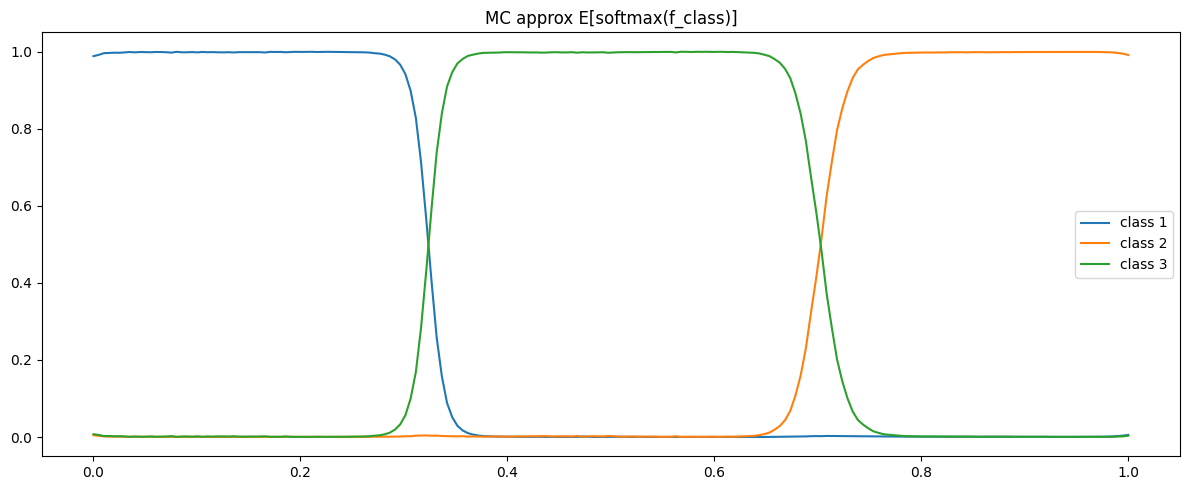

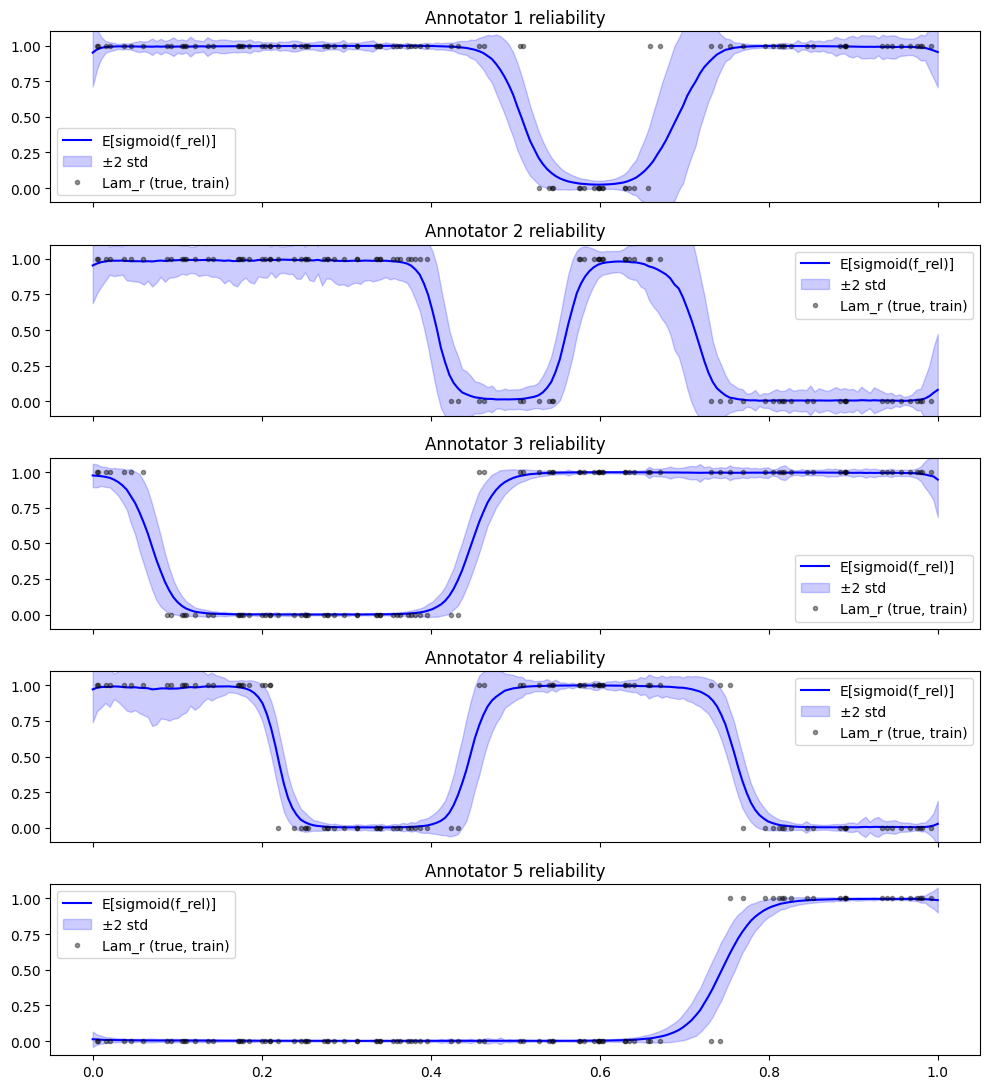

In [109]:
def build_X_lmc(X1d_np: np.ndarray, Q: int) -> torch.Tensor:
    X1d_np = X1d_np.reshape(-1, 1).astype(np.float32)
    N = X1d_np.shape[0]
    x_rep = np.tile(X1d_np, (Q, 1)).astype(np.float32)                  # (N*Q, 1)
    chan = np.repeat(np.arange(Q, dtype=np.int64), N).astype(np.float32) # channel ids as "integer-valued float"
    X2 = np.concatenate([chan.reshape(-1, 1), x_rep], axis=1)           # (N*Q, 2): [channel, x]
    return torch.tensor(X2, dtype=dtype, device=device)

def unstack_blocked(t: torch.Tensor, N: int, Q: int) -> torch.Tensor:
    # (N*Q,1) -> (N,Q)
    if t.ndim == 2 and t.shape[1] == 1:
        t = t.squeeze(1)
    return t.reshape(Q, N).T

# === MC predictive moments from latent posterior ===
def predict_mc_probs_from_latents(mu_lat: torch.Tensor, var_lat: torch.Tensor, K: int, R: int, S: int = 2000):
    """
    mu_lat, var_lat: (N, Q=K+R)
    Returns:
      p_class_mean: (N, K) approx E[softmax(f_class)]
      z_mean:       (N, R) approx E[sigmoid(f_rel)]
      plus optional variances if you want
    """
    N, Qloc = mu_lat.shape
    assert Qloc == K + R

    # sample f ~ N(mu, diag(var))
    eps = torch.randn((S, N, Qloc), device=mu_lat.device, dtype=mu_lat.dtype)
    f_s = mu_lat.unsqueeze(0) + torch.sqrt(var_lat.clamp_min(1e-12)).unsqueeze(0) * eps  # (S,N,Q)

    f_class = f_s[:, :, :K]              # (S,N,K)
    f_rel   = f_s[:, :, K:K+R]           # (S,N,R)

    p_class_s = torch.softmax(f_class, dim=-1)     # (S,N,K)
    z_s       = torch.sigmoid(f_rel)               # (S,N,R)

    p_class_mean = p_class_s.mean(dim=0)           # (N,K)
    z_mean       = z_s.mean(dim=0)                 # (N,R)

    # (opcional) varianzas predictivas para bandas
    p_class_var = p_class_s.var(dim=0, unbiased=False)
    z_var       = z_s.var(dim=0, unbiased=False)
    return p_class_mean, p_class_var, z_mean, z_var

# === Run prediction on Xtest ===
Ntest = Xtest.shape[0]
Q = K + R

Xte_lmc = build_X_lmc(Xtest, Q=Q)

with torch.inference_mode():
    mu_stacked, var_stacked = model.gpr.predict_f(Xte_lmc)  # (Ntest*Q,1)

mu_lat  = unstack_blocked(mu_stacked,  N=Ntest, Q=Q)  # (Ntest,Q)
var_lat = unstack_blocked(var_stacked, N=Ntest, Q=Q)  # (Ntest,Q)

p_mean, p_var, z_mean, z_var = predict_mc_probs_from_latents(mu_lat, var_lat, K=K, R=R, S=2000)

y_pred = torch.argmax(p_mean, dim=1) + 1
acc = (y_pred.cpu().numpy().reshape(-1,1).flatten() == ytest.flatten()).mean()
print("MC predictive accuracy vs ytest:", acc)

# === Plot class probabilities ===
plt.figure(figsize=(12, 5))
for k in range(K):
    plt.plot(Xtest.flatten(), p_mean[:, k].cpu().numpy(), label=f"class {k+1}")
plt.title("MC approx E[softmax(f_class)]")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# === Plot annotator reliability mean (+/- 2 std) like demo bands ===
fig, axes = plt.subplots(R, 1, figsize=(10, 2.2 * R), sharex=True)
if R == 1:
    axes = [axes]
for r in range(R):
    m = z_mean[:, r].cpu().numpy()
    s = np.sqrt(z_var[:, r].cpu().numpy())
    axes[r].plot(Xtest.flatten(), m, "b-", label="E[sigmoid(f_rel)]")
    axes[r].fill_between(Xtest.flatten(), m - 2*s, m + 2*s, color="b", alpha=0.2, label="±2 std")
    axes[r].plot(Xtrain.flatten(), np.asarray(Z_r[r]).flatten(), "k.", alpha=0.4, label="Lam_r (true, train)")
    axes[r].set_ylim(-0.1, 1.1)
    axes[r].set_title(f"Annotator {r+1} reliability")
    axes[r].legend(loc="best")
plt.tight_layout()
plt.show()

In [110]:
z_mean_np = z_mean.detach().cpu().numpy()   # (Ntest,R)
print("mean z per annotator (test):", z_mean_np.mean(axis=0))
print("min/max z overall:", z_mean_np.min(), z_mean_np.max())

for r in range(R):
    lam = np.asarray(Z_r[r]).reshape(-1)
    print(f"annot {r+1} true lambda train mean={lam.mean():.3f}  min={lam.min():.1f} max={lam.max():.1f}")

mean z per annotator (test): [0.81458937 0.55337815 0.61864702 0.52995588 0.25744654]
min/max z overall: 0.0005179897275110223 0.9988480208055871
annot 1 true lambda train mean=0.820  min=0.0 max=1.0
annot 2 true lambda train mean=0.650  min=0.0 max=1.0
annot 3 true lambda train mean=0.560  min=0.0 max=1.0
annot 4 true lambda train mean=0.510  min=0.0 max=1.0
annot 5 true lambda train mean=0.230  min=0.0 max=1.0
